# Indicator Kriging (Stage 1) — Visualization

This notebook visualizes the first stage of the two-stage kriging pipeline:
1. **Global indicator variogram** — a single spherical variogram fitted by pooling indicator semi-variance across all days (Haylock 2008, §31), loaded from `global_variograms.pkl`
2. **Zoomed-in maps** for several days showing:
   - A region with partial rainfall (some stations wet, some dry)
   - The spherical variogram range circle around a target grid cell
   - Stations used for prediction (inside the range)
   - The resulting indicator kriging map: P(rain) > 0.4 → wet vs dry

In [1]:
import sys, os, time
from pathlib import Path

# Two levels up from notebooks/03_results/ to project root
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
})

print(f"Working directory: {os.getcwd()}")

Working directory: /Users/etomengoi/Desktop/precip_interpolation_thesis


## 1. Load data & fit transforms

In [2]:
from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.transforms import (
    ProjectionTransform, IndicatorTransform, DetrendTransform,
)
from thesis.transforms.pipeline import TransformPipeline

cfg = Config()
registry = DataRegistry.from_config(cfg)

print("Loading ReKIS data...")
all_raw = registry.stations.load(cfg.date_start, cfg.date_end)
print(f"Loaded {len(all_raw):,} rows, {all_raw['station_id'].nunique()} stations")

# Fit pipeline (projection + indicator + detrend)
proj = ProjectionTransform(target_crs=cfg.study_area.target_crs)
ind  = IndicatorTransform(threshold_mm=cfg.wet_day_threshold_mm)
det  = DetrendTransform()

proj.fit(all_raw);  current = proj.apply(all_raw)
ind.fit(current);   current = ind.apply(current)
det.fit(current);   all_proc = det.apply(current)

print(f"Pipeline fitted. Shape: {all_proc.shape}")

Loading ReKIS data...
Loaded 56,558,580 rows, 2458 stations
Pipeline fitted. Shape: (56558580, 10)


## 2. Load global indicator variogram

Load the pre-fitted global variogram from `global_variograms.pkl`. If the indicator key is not yet present (pkl was generated before `fit_indicator()` was added), fit it here and save back.

In [3]:
from thesis.models.kriging.variogram_fitter import GlobalVariogramFitter

VGM_PATH = "results/ordinary_kriging/global_variograms.pkl"

payload = GlobalVariogramFitter.load_full(VGM_PATH)
global_vgm = payload["variograms"]

IND_KEY = ("indicator", "spherical")

if IND_KEY not in global_vgm or global_vgm[IND_KEY] is None:
    print("Indicator variogram not in pkl — fitting now...")
    # Group processed data by date
    grouped = {date: grp for date, grp in all_proc.groupby("date")}
    pool_procs = [grouped[d] for d in sorted(grouped.keys())]

    fitter = GlobalVariogramFitter(
        transforms=[], variogram_models=[],
        n_lags=cfg.kriging.variogram_nlags,
        max_lag_km=cfg.kriging.search_radius_km,
        min_pairs=30,
        n_jobs=6,
    )
    fitter._result = global_vgm
    fitter.fit_indicator(pool_procs)

    # Save updated pkl
    fitter._emp_data = payload.get("empirical", {})
    fitter._emp_data.update(fitter._emp_data)  # merge indicator empirical
    fitter.save(VGM_PATH)
    global_vgm = fitter._result
    print("Indicator variogram fitted and saved.")
else:
    print("Indicator variogram loaded from pkl.")

ind_info = global_vgm[IND_KEY]
ind_params = ind_info["params_dict"]
print(f"\nGlobal indicator variogram (spherical):")
print(f"  nugget = {ind_params['nugget']:.4f}")
print(f"  psill  = {ind_params['psill']:.4f}")
print(f"  sill   = {ind_params['nugget'] + ind_params['psill']:.4f}")
print(f"  range  = {ind_params['range']/1e3:.0f} km")

Indicator variogram loaded from pkl.

Global indicator variogram (spherical):
  nugget = 0.0584
  psill  = 0.0946
  sill   = 0.1530
  range  = 416 km


## 3. Select days & build prediction grid

In [4]:
from thesis.datasets.protocols import PredictionGrid

grid = PredictionGrid.from_config(cfg, dem=registry.dem)
H, W = grid.shape
print(f"Grid: {grid.n_cells():,} cells, shape {grid.shape}")

# Days with partial rainfall (30-70% wet) — interesting wet/dry boundary
all_proc['date'] = pd.to_datetime(all_proc['date'])
daily_wet = all_proc.groupby('date')['rain_indicator'].mean()

selected_dates = ['2013-11-24']

for d in selected_dates:
    dt = pd.Timestamp(d)
    frac = daily_wet[dt]
    print(f"  {d}: wet fraction = {frac:.1%}")

Grid: 189,648 cells, shape (439, 432)
  2013-11-24: wet fraction = 48.0%


## 4. Run indicator kriging using global variogram

Uses `_build_pykrige_ok()` with the pre-fitted global indicator variogram — same code path as production `OrdinaryKrigingModel.fit()`.

In [5]:
from thesis.models.kriging.ordinary import _build_pykrige_ok, _predict_chunked


def run_indicator_kriging(date_str: str):
    """Run Stage 1 indicator kriging for a single day using global variogram.
    
    Returns dict with p_rain, wet_grid, station arrays, and global variogram params.
    """
    day = all_proc[all_proc['date'] == date_str].copy()
    
    x_st = day['x_proj'].values
    y_st = day['y_proj'].values
    z_ind = day['rain_indicator'].values.astype(float)
    
    n_wet = int(z_ind.sum())
    n_total = len(z_ind)
    print(f"{date_str}: {n_total} stations, {n_wet} wet ({n_wet/n_total:.1%})")
    
    # Build indicator kriging with global variogram (same as OrdinaryKrigingModel.fit)
    ok = _build_pykrige_ok(x_st, y_st, z_ind, ind_info["model"], ind_params)
    
    # Predict P(rain) on full grid
    gx_flat = grid.coords_proj[:, 0]
    gy_flat = grid.coords_proj[:, 1]
    p_rain_flat, _ = _predict_chunked(ok, gx_flat, gy_flat)
    p_rain = np.clip(p_rain_flat, 0.0, 1.0).reshape(H, W)
    wet_grid = p_rain > cfg.kriging.indicator_probability_threshold
    
    print(f"  Grid wet cells: {wet_grid.sum():,} / {wet_grid.size:,} ({wet_grid.mean():.1%})")
    
    return {
        'ok': ok,
        'p_rain': p_rain,
        'wet_grid': wet_grid,
        'stations': {'x': x_st, 'y': y_st, 'indicator': z_ind},
    }

## 5. Run indicator kriging for selected days (global variogram)

In [6]:
results = {}
for d in selected_dates:
    t0 = time.time()
    results[d] = run_indicator_kriging(d)
    print(f"  Elapsed: {time.time()-t0:.1f}s\n")

2013-11-24: 2458 stations, 1180 wet (48.0%)
  Grid wet cells: 84,628 / 189,648 (44.6%)
  Elapsed: 25.0s



## 6. Global indicator variogram visualization

Single spherical variogram fitted by pooling indicator semi-variance across all ~23k days (Haylock 2008, §31). The same parameters are used for every day.

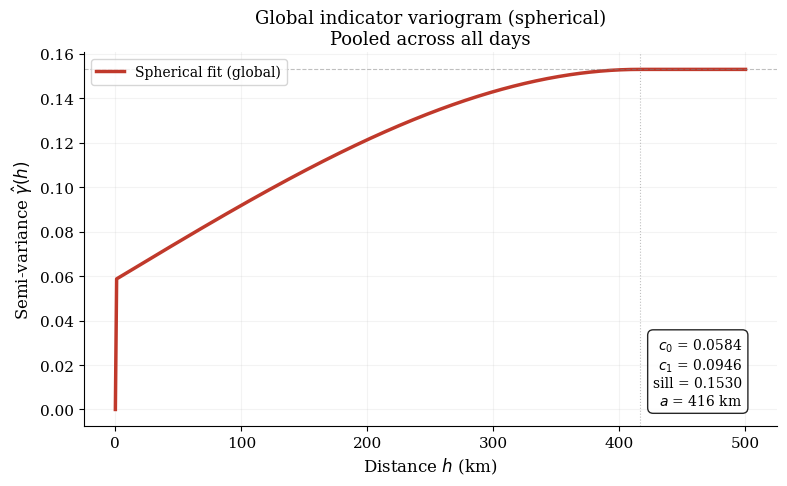

Saved: images/indicator_variogram_global.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

nugget = ind_params['nugget']
psill  = ind_params['psill']
a      = ind_params['range']

# Empirical variogram from pkl (if available)
emp = payload.get("empirical", {}).get("indicator", None)
if emp is not None:
    lag_km = emp["lag_km"]
    gamma  = emp["gamma"]
    count  = emp["count"]
    valid  = np.isfinite(gamma) & (count >= 30)
    sizes  = np.clip(count[valid] / count[valid].max() * 120, 15, 120)
    ax.scatter(lag_km[valid], gamma[valid], s=sizes, color='steelblue',
               zorder=5, label='Empirical (pooled)')

# Fitted spherical curve
h = np.linspace(0, 500, 500)
h_m = h * 1e3
gamma_fit = np.where(
    h_m <= a,
    nugget + psill * (1.5 * h_m / a - 0.5 * (h_m / a) ** 3),
    nugget + psill,
)
gamma_fit[0] = 0

ax.plot(h, gamma_fit, color='#c0392b', lw=2.5, label='Spherical fit (global)')
ax.axhline(nugget + psill, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.axvline(a / 1e3, color='gray', ls=':', lw=0.8, alpha=0.5)

ax.set_xlabel('Distance $h$ (km)')
ax.set_ylabel(r'Semi-variance $\hat{\gamma}(h)$')
ax.set_title('Global indicator variogram (spherical)\nPooled across all days')

info = (f"$c_0$ = {nugget:.4f}\n$c_1$ = {psill:.4f}\n"
        f"sill = {nugget+psill:.4f}\n$a$ = {a/1e3:.0f} km")
ax.text(0.95, 0.05, info, transform=ax.transAxes, fontsize=10,
        ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85))

for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
ax.grid(True, alpha=0.15)
ax.legend(loc='upper left', fontsize=10)

fig.tight_layout()
fig.savefig('images/indicator_variogram_global.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: images/indicator_variogram_global.png")

## 7. Zoomed-in visualization: range circle + stations + wet/dry map

For each day we:
1. Find a target grid cell near the wet/dry boundary
2. Draw the global spherical variogram range circle around it
3. Show which stations fall inside (used for prediction) and outside
4. Show the resulting P(rain) and the binary wet/dry classification (P > 0.4)

In [8]:
def find_boundary_cell(p_rain, threshold=0.4):
    """Find a grid cell near the wet/dry boundary (P ~ threshold)."""
    dist = np.abs(p_rain - threshold)
    margin = 80
    mask = np.ones_like(dist, dtype=bool)
    mask[:margin, :] = False
    mask[-margin:, :] = False
    mask[:, :margin] = False
    mask[:, -margin:] = False
    dist[~mask] = 999
    return np.unravel_index(np.argmin(dist), dist.shape)


def plot_indicator_day(date_str, result, zoom_radius_km=150, save=True):
    """3-panel figure: full P(rain) | zoomed stations+range | binary wet/dry."""
    r = result
    p_rain = r['p_rain']
    wet_grid = r['wet_grid']
    st = r['stations']
    vgm_range = ind_params['range']  # global variogram range
    
    gx_2d = grid.coords_proj[:, 0].reshape(H, W)
    gy_2d = grid.coords_proj[:, 1].reshape(H, W)
    
    row_t, col_t = find_boundary_cell(p_rain)
    target_x = gx_2d[row_t, col_t]
    target_y = gy_2d[row_t, col_t]
    
    zoom_r = zoom_radius_km * 1e3
    x_lo, x_hi = target_x - zoom_r, target_x + zoom_r
    y_lo, y_hi = target_y - zoom_r, target_y + zoom_r
    
    col_lo = max(0, np.searchsorted(gx_2d[0, :], x_lo) - 1)
    col_hi = min(W, np.searchsorted(gx_2d[0, :], x_hi) + 1)
    row_lo = max(0, np.searchsorted(gy_2d[:, 0], y_lo) - 1)
    row_hi = min(H, np.searchsorted(gy_2d[:, 0], y_hi) + 1)
    
    dist_to_target = np.sqrt((st['x'] - target_x)**2 + (st['y'] - target_y)**2)
    inside_range = dist_to_target <= vgm_range
    in_zoom = ((st['x'] >= x_lo) & (st['x'] <= x_hi) &
               (st['y'] >= y_lo) & (st['y'] <= y_hi))
    
    n_wet_st = int(st['indicator'].sum())
    n_total_st = len(st['indicator'])
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 7.5))
    fig.subplots_adjust(bottom=0.22)
    
    # --- Panel 1: Full domain P(rain) ---
    ax1 = axes[0]
    ext = [gx_2d[0,0]/1e3, gx_2d[0,-1]/1e3, gy_2d[0,0]/1e3, gy_2d[-1,0]/1e3]
    im1 = ax1.imshow(p_rain, cmap='RdYlBu', vmin=0, vmax=1, origin='lower', extent=ext)
    plt.colorbar(im1, ax=ax1, label='P(rain)', shrink=0.8)
    rect = plt.Rectangle((x_lo/1e3, y_lo/1e3), 2*zoom_r/1e3, 2*zoom_r/1e3,
                          lw=2, edgecolor='black', facecolor='none', ls='--')
    ax1.add_patch(rect)
    ax1.set_title(f'P(rain) — full domain\n{date_str}  '
                  f'({n_wet_st}/{n_total_st} stations wet)')
    ax1.set_xlabel('Easting (km)')
    ax1.set_ylabel('Northing (km)')
    
    # --- Panel 2: Zoomed P(rain) + stations + range circle ---
    ax2 = axes[1]
    zoom_ext = [x_lo/1e3, x_hi/1e3, y_lo/1e3, y_hi/1e3]
    p_zoom = p_rain[row_lo:row_hi, col_lo:col_hi]
    ax2.imshow(p_zoom, cmap='RdYlBu', vmin=0, vmax=1, origin='lower',
               extent=zoom_ext, alpha=0.7)
    
    circle = plt.Circle((target_x/1e3, target_y/1e3), vgm_range/1e3,
                         fill=False, edgecolor='#c0392b', lw=2.5)
    ax2.add_patch(circle)
    ax2.plot(target_x/1e3, target_y/1e3, marker='x', color='#c0392b',
             markersize=12, markeredgewidth=3, zorder=10)
    
    for mask_sel, marker, alpha in [(in_zoom & inside_range, 'o', 0.9),
                                     (in_zoom & ~inside_range, 's', 0.4)]:
        if mask_sel.sum() == 0:
            continue
        wet_m = st['indicator'][mask_sel] == 1
        if wet_m.sum() > 0:
            ax2.scatter(st['x'][mask_sel][wet_m]/1e3, st['y'][mask_sel][wet_m]/1e3,
                       c='steelblue', marker=marker, s=40, alpha=alpha,
                       edgecolors='black', linewidths=0.5, zorder=8)
        if (~wet_m).sum() > 0:
            ax2.scatter(st['x'][mask_sel][~wet_m]/1e3, st['y'][mask_sel][~wet_m]/1e3,
                       c='#e8e8e8', marker=marker, s=40, alpha=alpha,
                       edgecolors='black', linewidths=0.5, zorder=8)
    
    legend_el = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
               markeredgecolor='black', markersize=8, label='Wet (in range)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#e8e8e8',
               markeredgecolor='black', markersize=8, label='Dry (in range)'),
    ]
    ax2.legend(handles=legend_el, loc='upper center',
               bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8.5,
               framealpha=0.9, columnspacing=1.0)
    
    n_in = inside_range.sum()
    n_in_wet = int((st['indicator'][inside_range] == 1).sum())
    ax2.set_title(f'Zoomed: stations + variogram range\n'
                  f'{n_in} stations in range ({n_in_wet} wet, {n_in - n_in_wet} dry)')
    ax2.set_xlim(zoom_ext[0], zoom_ext[1])
    ax2.set_ylim(zoom_ext[2], zoom_ext[3])
    ax2.set_xlabel('Easting (km)')
    ax2.set_aspect('equal')
    
    # --- Panel 3: Binary wet/dry map (zoomed) ---
    ax3 = axes[2]
    wet_zoom = wet_grid[row_lo:row_hi, col_lo:col_hi].astype(float)
    cmap_wd = ListedColormap(['#f5f5f5', 'steelblue'])
    ax3.imshow(wet_zoom, cmap=cmap_wd, vmin=0, vmax=1, origin='lower', extent=zoom_ext)
    
    p_zoom_full = p_rain[row_lo:row_hi, col_lo:col_hi]
    xc = np.linspace(zoom_ext[0], zoom_ext[1], p_zoom_full.shape[1])
    yc = np.linspace(zoom_ext[2], zoom_ext[3], p_zoom_full.shape[0])
    ax3.contour(xc, yc, p_zoom_full, levels=[0.4], colors=['#c0392b'],
                linewidths=1.5, linestyles='--')
    
    wet_m = st['indicator'][in_zoom] == 1
    if wet_m.sum() > 0:
        ax3.scatter(st['x'][in_zoom][wet_m]/1e3, st['y'][in_zoom][wet_m]/1e3,
                   c='steelblue', marker='o', s=25, edgecolors='black',
                   linewidths=0.5, zorder=8, alpha=0.7)
    if (~wet_m).sum() > 0:
        ax3.scatter(st['x'][in_zoom][~wet_m]/1e3, st['y'][in_zoom][~wet_m]/1e3,
                   c='white', marker='o', s=25, edgecolors='black',
                   linewidths=0.5, zorder=8, alpha=0.7)
    
    legend_wd = [
        mpatches.Patch(facecolor='steelblue', label='Predicted wet (P > 0.4)'),
        mpatches.Patch(facecolor='#f5f5f5', edgecolor='gray', label='Predicted dry (P ≤ 0.4)'),
        Line2D([0],[0], color='#c0392b', ls='--', lw=1.5, label='P = 0.4 contour'),
    ]
    ax3.legend(handles=legend_wd, loc='upper center',
               bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8.5,
               framealpha=0.9, columnspacing=1.0)
    
    ax3.set_title('Binary wet/dry classification\n(P > 0.4 threshold)')
    ax3.set_xlim(zoom_ext[0], zoom_ext[1])
    ax3.set_ylim(zoom_ext[2], zoom_ext[3])
    ax3.set_xlabel('Easting (km)')
    ax3.set_aspect('equal')
    
    if save:
        fname = f'images/indicator_kriging_{date_str}.png'
        fig.savefig(fname, dpi=200, bbox_inches='tight', facecolor='white')
        print(f"  Saved: {fname}")
    plt.show()

## 8. Generate plots for all selected days


  2013-11-24
  Saved: images/indicator_kriging_2013-11-24.png


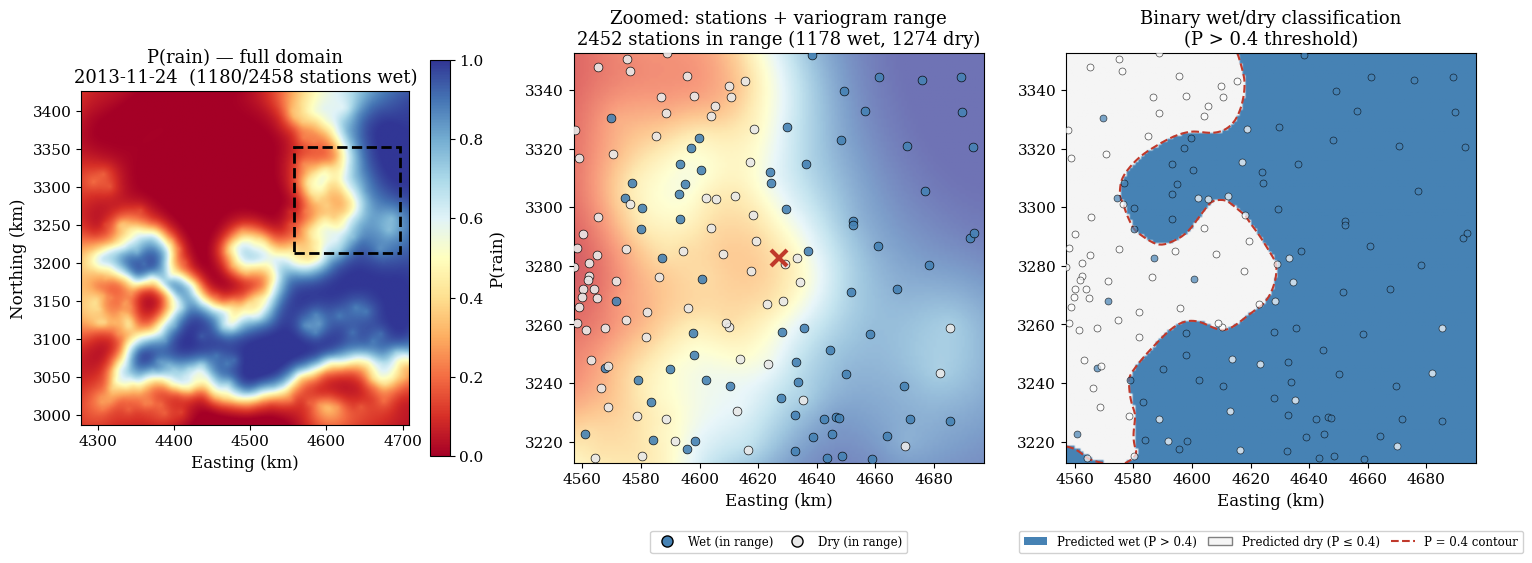

In [9]:
for d in selected_dates:
    print(f"\n{'='*60}")
    print(f"  {d}")
    print(f"{'='*60}")
    plot_indicator_day(d, results[d], zoom_radius_km=70)

## 9. Summary

Global indicator variogram parameters (same for all days) and per-day prediction statistics.

In [10]:
print("Global indicator variogram (spherical):")
print(f"  nugget = {ind_params['nugget']:.4f}")
print(f"  psill  = {ind_params['psill']:.4f}")
print(f"  sill   = {ind_params['nugget'] + ind_params['psill']:.4f}")
print(f"  range  = {ind_params['range']/1e3:.0f} km")
print()

rows = []
for d in selected_dates:
    r = results[d]
    st = r['stations']
    n_wet = int(st['indicator'].sum())
    n_total = len(st['indicator'])
    rows.append({
        'Date': d,
        'Wet fraction': f"{n_wet/n_total:.1%}",
        'Wet grid cells': f"{r['wet_grid'].sum():,}",
        'Grid wet %': f"{r['wet_grid'].mean():.1%}",
    })

pd.DataFrame(rows)

Global indicator variogram (spherical):
  nugget = 0.0584
  psill  = 0.0946
  sill   = 0.1530
  range  = 416 km



,Date,Wet fraction,Wet grid cells,Grid wet %
0,2013-11-24,48.0%,"84,628",44.6%
